In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/nlp_project'
os.makedirs(project_path, exist_ok=True)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, f1_score, recall_score
from sklearn.model_selection import train_test_split

In [4]:
from datasets import Dataset, DatasetDict
from transformers import ( AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline)

In [5]:
## Read Training Data
df_train = pd.read_csv(f"{project_path}/training_data.csv", sep="\t", header=None, names=["label", "text"])

In [6]:
## Read Testing Data
df_test = pd.read_csv(f"{project_path}/testing_data.csv", sep="\t", header=None, names=["label", "text"])

In [7]:
print(df_train.head())
print(df_test.head())
print(df_train.shape, df_test.shape)

   label                                               text
0      0  donald trump sends out embarrassing new year‚s...
1      0  drunk bragging trump staffer started russian c...
2      0  sheriff david clarke becomes an internet joke ...
3      0  trump is so obsessed he even has obama‚s name ...
4      0  pope francis just called out donald trump duri...
  label                                               text
0     2  copycat muslim terrorist arrested with assault...
1     2  wow! chicago protester caught on camera admits...
2     2   germany's fdp look to fill schaeuble's big shoes
3     2  mi school sends welcome back packet warning ki...
4     2  u.n. seeks 'massive' aid boost amid rohingya '...
(34152, 2) (9984, 2)


In [8]:
df_train.head()

,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [9]:
X = df_train['text']
y = df_train['label']

from datasets.utils import stratify

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [10]:
dataset = DatasetDict({ "train": Dataset.from_dict({ "text": X_train.tolist(), "label": y_train.tolist(), }), "test": Dataset.from_dict({ "text": X_test.tolist(), "label": y_test.tolist(), }), })
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 27321
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 6831
    })
})

In [13]:
model = AutoModelForSequenceClassification.from_pretrained("mrm8488/bert-tiny-finetuned-fake-news-detection")
tokenizer = AutoTokenizer.from_pretrained("mrm8488/bert-tiny-finetuned-fake-news-detection")

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mrm8488/bert-tiny-finetuned-fake-news-detection
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
print(model.config.id2label)

{0: 'LABEL_0', 1: 'LABEL_1'}


In [15]:
#def tokenize_dataset(dataset):
 #   return tokenizer(dataset["text"])
#dataset = dataset.map(tokenize_dataset, batched=True)

def tokenize_dataset(batch):
    return tokenizer(
        batch["text"],
        truncation=True
    )

tokenized_dataset = dataset.map(tokenize_dataset, batched=True)

Map:   0%|          | 0/27321 [00:00<?, ? examples/s]

Map:   0%|          | 0/6831 [00:00<?, ? examples/s]

In [16]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [17]:
model_save_path = f"{project_path}/bert_tiny_finetuned_fake_news_detection"

training_args = TrainingArguments(
    output_dir=(f"{project_path}/distilbert-base-uncased"),
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    push_to_hub=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.206294,0.129734
2,0.133966,0.125857


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.en

TrainOutput(global_step=6832, training_loss=0.22681799761305368, metrics={'train_runtime': 106.6494, 'train_samples_per_second': 512.352, 'train_steps_per_second': 64.06, 'total_flos': 3704090076600.0, 'train_loss': 0.22681799761305368, 'epoch': 2.0})

In [21]:
trainer.save_model(f"{project_path}/bert_tiny_finetuned_fake_news_detection")
tokenizer.save_pretrained(f"{project_path}/bert_tiny_finetuned_fake_news_detection")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/nlp_project/bert_tiny_finetuned_fake_news_detection/tokenizer_config.json',
 '/content/drive/MyDrive/nlp_project/bert_tiny_finetuned_fake_news_detection/tokenizer.json')

In [22]:
predictions = trainer.predict(tokenized_dataset['test'])
preds = predictions.predictions.argmax(axis=1)
true_labels = predictions.label_ids

In [23]:
print("BERT Tiny fine-tuned fake news detection")
print("Accuracy:", accuracy_score(true_labels, preds))
print(classification_report(true_labels, preds))
print(confusion_matrix(true_labels, preds))

BERT Tiny fine-tuned fake news detection
Accuracy: 0.9667691406821841
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3515
           1       0.97      0.97      0.97      3316

    accuracy                           0.97      6831
   macro avg       0.97      0.97      0.97      6831
weighted avg       0.97      0.97      0.97      6831

[[3403  112]
 [ 115 3201]]


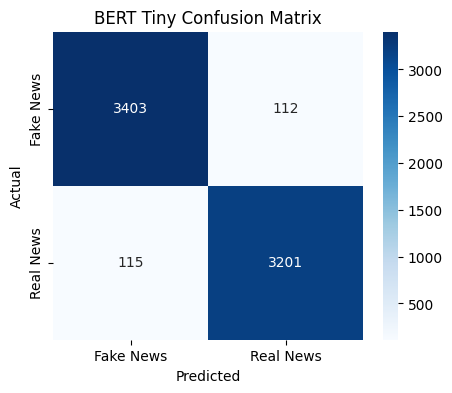

In [24]:
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake News", "Real News"], yticklabels=["Fake News", "Real News"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Tiny Confusion Matrix")
plt.show()

In [25]:
df_test.head()

,label,text
0,2,copycat muslim terrorist arrested with assault...
1,2,wow! chicago protester caught on camera admits...
2,2,germany's fdp look to fill schaeuble's big shoes
3,2,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...


In [26]:
text = df_test['text'].tolist()

In [28]:
from transformers import pipeline

classifier = pipeline("text-classification", model=(f"{project_path}/bert_tiny_finetuned_fake_news_detection"))
prediction_results = classifier(text)

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

In [ ]:
prediction_results

[{'label': 'LABEL_0', 'score': 0.9999508857727051},
 {'label': 'LABEL_0', 'score': 0.9999786615371704},
 {'label': 'LABEL_1', 'score': 0.9999909400939941},
 {'label': 'LABEL_0', 'score': 0.9998311996459961},
 {'label': 'LABEL_1', 'score': 0.9999909400939941},
 {'label': 'LABEL_0', 'score': 0.9999933242797852},
 {'label': 'LABEL_1', 'score': 0.9999911785125732},
 {'label': 'LABEL_0', 'score': 0.9999911785125732},
 {'label': 'LABEL_1', 'score': 0.9999885559082031},
 {'label': 'LABEL_1', 'score': 0.9999903440475464},
 {'label': 'LABEL_1', 'score': 0.999988317489624},
 {'label': 'LABEL_1', 'score': 0.9999852180480957},
 {'label': 'LABEL_0', 'score': 0.9999690055847168},
 {'label': 'LABEL_0', 'score': 0.999993085861206},
 {'label': 'LABEL_0', 'score': 0.9906845092773438},
 {'label': 'LABEL_0', 'score': 0.9999910593032837},
 {'label': 'LABEL_0', 'score': 0.9999923706054688},
 {'label': 'LABEL_0', 'score': 0.9999818801879883},
 {'label': 'LABEL_1', 'score': 0.9999897480010986},
 {'label': 'LA

In [ ]:
df_test['predicted_label'] = [r['label'] for r in prediction_results]

In [ ]:
df_test['confidence'] = [r['score'] for r in prediction_results]

In [29]:
label_map = {
    "FAKE": 0,
    "REAL": 1,
    "LABEL_0": 0,
    "LABEL_1": 1
}

df_test["predicted_label"] = [
    label_map[result["label"]] for result in prediction_results
]

df_test["confidence"] = [
    result["score"] for result in prediction_results
]

df_test.head()

,label,text,predicted_label,confidence
0,2,copycat muslim terrorist arrested with assault...,0,0.974862
1,2,wow! chicago protester caught on camera admits...,0,0.999496
2,2,germany's fdp look to fill schaeuble's big shoes,1,0.999474
3,2,mi school sends welcome back packet warning ki...,1,0.986721
4,2,u.n. seeks 'massive' aid boost amid rohingya '...,1,0.999400


In [30]:
final_submission = df_test[["label", "text"]].copy()
final_submission["label"] = df_test["predicted_label"]

final_submission.to_csv(
    f"{project_path}/testing_data_predictions_bert_tiny.csv",
    sep="\t",
    header=False,
    index=False
)

final_submission.head()

,label,text
0,0,copycat muslim terrorist arrested with assault...
1,0,wow! chicago protester caught on camera admits...
2,1,germany's fdp look to fill schaeuble's big shoes
3,1,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...


In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import os

predictions = trainer.predict(tokenized_dataset["test"])

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

accuracy = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("BERT Tiny Fine-Tuned Fake News Detection")
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(cm)

BERT Tiny Fine-Tuned Fake News Detection
Accuracy: 0.9667691406821841

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3515
           1       0.97      0.97      0.97      3316

    accuracy                           0.97      6831
   macro avg       0.97      0.97      0.97      6831
weighted avg       0.97      0.97      0.97      6831


Confusion Matrix:
[[3403  112]
 [ 115 3201]]


In [32]:
results_path = f"{project_path}/bert_tiny_transformer_results.txt"

with open(results_path, "w") as f:
    f.write("BERT Tiny Fine-Tuned Fake News Detection\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Model used: mrm8488/bert-tiny-finetuned-fake-news-detection\n")
    f.write(f"Saved model path: {model_save_path}\n\n")
    f.write(f"Accuracy: {accuracy}\n\n")
    f.write("Classification Report:\n")
    f.write(report)
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("Saved results to:", results_path)

Saved results to: /content/drive/MyDrive/nlp_project/bert_tiny_transformer_results.txt


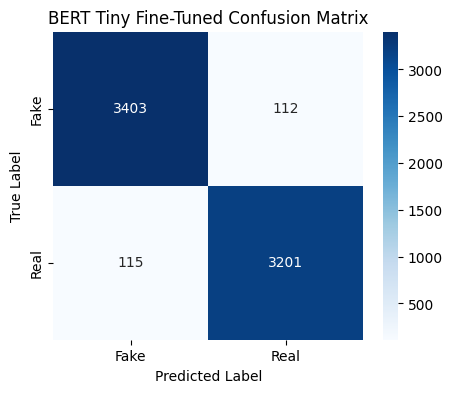

Saved confusion matrix heatmap to: /content/drive/MyDrive/nlp_project/bert_tiny_confusion_matrix_heatmap.png


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERT Tiny Fine-Tuned Confusion Matrix")

cm_path = f"{project_path}/bert_tiny_confusion_matrix_heatmap.png"

plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix heatmap to:", cm_path)

In [34]:
# Calculating key metrics

metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision (macro)": precision_score(y_true, y_pred, average="macro"),
    "Recall (macro)": recall_score(y_true, y_pred, average="macro"),
    "F1-score (macro)": f1_score(y_true, y_pred, average="macro")
}

metrics_df = pd.DataFrame({
    "Metric": list(metrics.keys()),
    "Score": list(metrics.values())
})

print(metrics_df)

              Metric     Score
0           Accuracy  0.966769
1  Precision (macro)  0.966752
2     Recall (macro)  0.966728
3   F1-score (macro)  0.966740


/tmp/ipykernel_3728/3210476543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


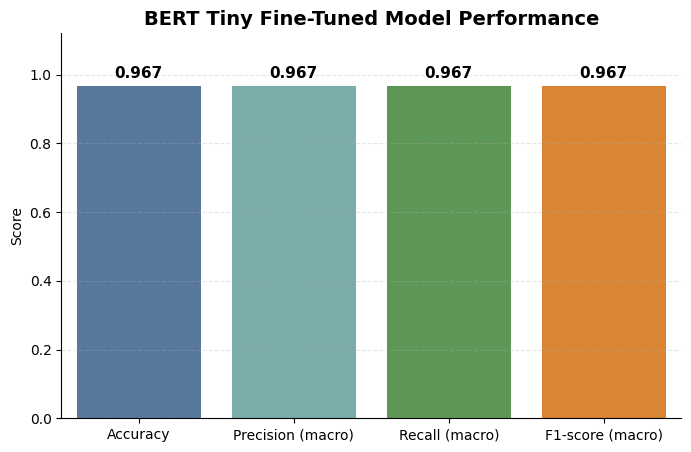

Saved metrics bar plot to: /content/drive/MyDrive/nlp_project/bert_tiny_metrics_barplot.png


In [37]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=metrics_df,
    x="Metric",
    y="Score",
    palette=["#4C78A8", "#72B7B2", "#54A24B", "#F58518"]
)

plt.ylim(0, 1.12)
plt.title("BERT Tiny Fine-Tuned Model Performance", fontsize=14, weight="bold")
plt.ylabel("Score")
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.3)


for i, row in metrics_df.iterrows():
    ax.text(
        i,
        row["Score"] + 0.015,
        f"{row['Score']:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold"
    )

sns.despine()

metrics_plot_path = f"{project_path}/bert_tiny_metrics_barplot.png"

plt.savefig(metrics_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved metrics bar plot to:", metrics_plot_path)